# Titanic Survival Prediction - Exploratory Data Analysis

This notebook explores the Titanic dataset and identifies factors that may affect passenger survival.

In [24]:
# =========================================
# 1. Import Libraries
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [26]:
# =========================================
# 2. Load Dataset
# =========================================

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [25]:
# =========================================
# 3. Data Overview
# =========================================

train_df.head()
train_df.info()
train_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   PassengerId    891 non-null    int64   
 1   Survived       891 non-null    int64   
 2   Pclass         891 non-null    int64   
 3   Name           891 non-null    str     
 4   Sex            891 non-null    str     
 5   Age            714 non-null    float64 
 6   SibSp          891 non-null    int64   
 7   Parch          891 non-null    int64   
 8   Ticket         891 non-null    str     
 9   Fare           891 non-null    float64 
 10  Cabin          204 non-null    str     
 11  Embarked       889 non-null    str     
 12  SurvivalLabel  342 non-null    str     
 13  FamilySize     891 non-null    int64   
 14  AgeFilled      891 non-null    float64 
 15  AgeGroup       891 non-null    category
 16  FareGroup      891 non-null    category
dtypes: category(2), float64(3), int64(6), str(6)
m

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,AgeFilled
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602,29.361582
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459,13.019697
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000,0.420000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000,22.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000,28.000000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000,35.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000,80.000000


In [ ]:
# =========================================
# 4. Missing Values Analysis
# =========================================

train_df.isnull().sum()

### Findings

- Age contains missing values.
- Cabin contains many missing values.
- Embarked contains a few missing values.

## Gender Analysis

In this section, we investigate the relationship between passenger gender and survival.

Our goal is to determine whether male and female passengers had different survival rates and to identify the impact of gender on survival outcomes.

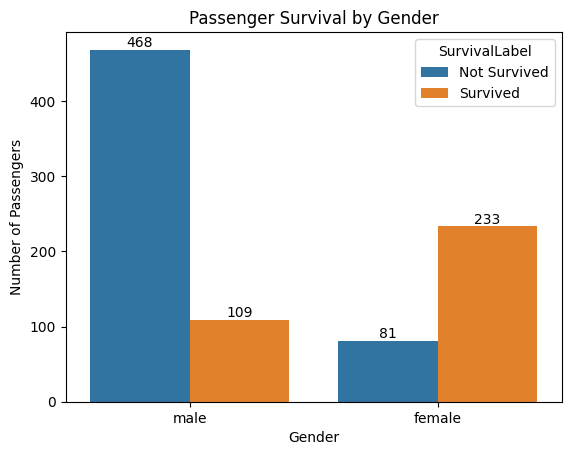

In [ ]:
# =========================================
# 5. Gender Analysis
# =========================================
# Visualize the number of passengers by gender,
# separated by survival status
train_df["SurvivalLabel"] = train_df["Survived"].map({
    0: "Not Survived",
    1: "Survived"
})
ax = sns.countplot(
    data=train_df,
    x="Sex",
    hue="SurvivalLabel"
)

# Display the exact count on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Passenger Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

### Key Findings

- Female passengers had significantly higher survival rates than male passengers.
- Gender appears to be one of the strongest factors associated with survival.
- Male passengers experienced substantially lower survival rates across the dataset.

## Family Analysis

In this section, we explore the effect of family size on passenger survival.

A new feature called `FamilySize` is created using the number of siblings/spouses (`SibSp`) and parents/children (`Parch`) traveling with each passenger.

The objective is to understand whether traveling alone or with family influenced survival chances.

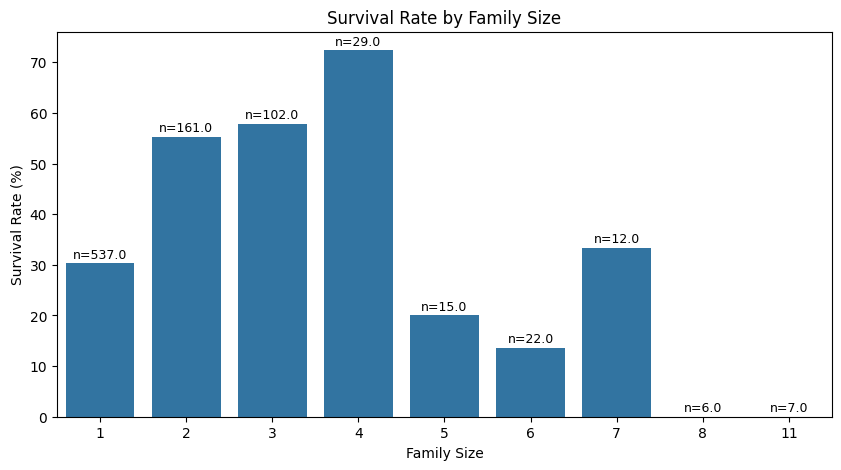

In [ ]:
# =========================================
# 6. Family Analysis
# =========================================

# Calculate survival rate and sample size for each family size group
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1
family_stats = (
    train_df.groupby("FamilySize")
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "count")
    )
    .reset_index()
)

# Convert survival rate to percentage
family_stats["SurvivalRate"] *= 100

# Create visualization
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=family_stats,
    x="FamilySize",
    y="SurvivalRate"
)

# Add sample size annotations on top of bars
for i, row in family_stats.iterrows():
    ax.text(
        i,
        row["SurvivalRate"] + 1,
        f'n={row["Count"]}',
        ha='center',
        fontsize=9
    )

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

plt.show()

### Key Findings

- Passengers traveling with small-to-medium-sized families had higher survival rates.
- Traveling alone was associated with lower survival rates.
- Very large families showed lower survival rates compared to medium-sized families.
- Family size appears to influence survival outcomes.

## Family and Gender Analysis

This section combines family size and gender to investigate how these factors interact.

We analyze whether the effect of family size on survival differs between male and female passengers.

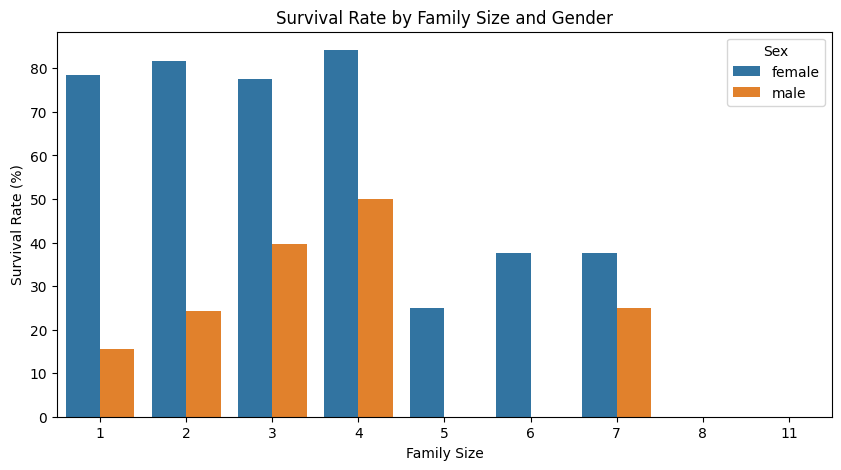

,FamilySize,Sex,SurvivalRate,Count
0,1,female,78.571429,126
1,1,male,15.571776,411
2,2,female,81.609195,87
3,2,male,24.324324,74
4,3,female,77.551020,49
5,3,male,39.622642,53
6,4,female,84.210526,19
7,4,male,50.000000,10
8,5,female,25.000000,12
9,5,male,0.000000,3


In [ ]:
# =========================================
# 6. Family & Gender Analysis
# =========================================

# Calculate survival rate and sample size for each group
survival_gender_family = (
    train_df.groupby(["FamilySize", "Sex"])
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "count")
    )
    .reset_index()
)

# Convert survival rate to percentage
survival_gender_family["SurvivalRate"] *= 100

# Create visualization
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=survival_gender_family,
    x="FamilySize",
    y="SurvivalRate",
    hue="Sex"
)

# Add labels
plt.title("Survival Rate by Family Size and Gender")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

plt.show()

# Group data by FamilySize and Sex to compute:
# - Survival rate (mean of Survived)
# - Number of passengers in each group
group_stats = (
    train_df.groupby(["FamilySize", "Sex"])
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "count")
    )
    .reset_index()
)

# Convert survival rate from ratio (0–1) to percentage (0–100)
group_stats["SurvivalRate"] *= 100

# Sort groups by family size (most reliable groups first)
group_stats = group_stats.sort_values(
    "FamilySize"
)

# Display result
group_stats

### Key Findings

- Female passengers maintained high survival rates across most family sizes.
- Male passengers benefited from traveling with family compared to traveling alone.
- The relationship between family size and survival differs between males and females.
- Gender remains a stronger predictor of survival than family size alone.

## Passenger Class Analysis

In this section, we examine the relationship between passenger class (`Pclass`) and survival.

Passenger class can be considered an indicator of socioeconomic status and access to resources during the evacuation process.

The goal is to determine whether passengers from higher classes had a greater chance of survival.

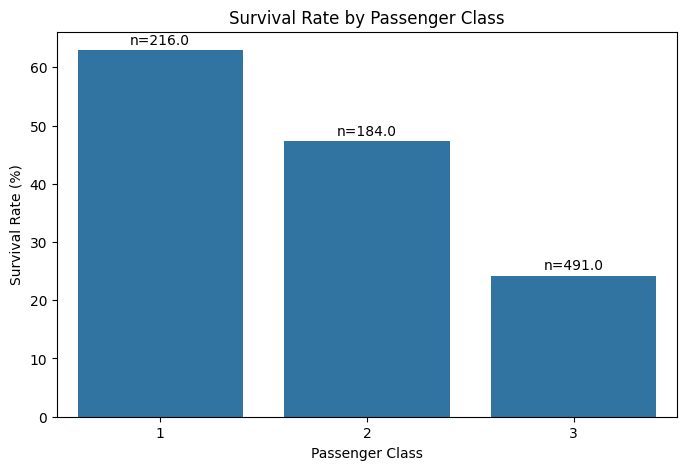

In [ ]:
# =========================================
# 7. Passenger Class Analysis
# =========================================

# Calculate survival rate and sample size for each passenger class
pclass_stats = (
    train_df.groupby("Pclass")
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "count")
    )
    .reset_index()
)

# Convert survival rate to percentage
pclass_stats["SurvivalRate"] *= 100
pclass_stats

# Visualize survival rate by passenger class
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=pclass_stats,
    x="Pclass",
    y="SurvivalRate"
)

# Add sample size annotations
for i, row in pclass_stats.iterrows():
    ax.text(
        i,
        row["SurvivalRate"] + 1,
        f'n={row["Count"]}',
        ha='center'
    )

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

### Key Findings

- First-class passengers had substantially higher survival rates than third-class passengers.
- Survival rates decreased as passenger class decreased.
- Passenger class appears to be a strong indicator of survival probability.
- Socioeconomic status may have influenced access to evacuation resources.

In [ ]:
# =========================================
# 7. Passenger Class Analysis
# =========================================
# Calculate survival rate by passenger class and gender
pclass_gender_stats = (
    train_df.groupby(["Pclass", "Sex"])
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "count")
    )
    .reset_index()
)

# Convert survival rate to percentage
pclass_gender_stats["SurvivalRate"] *= 100

pclass_gender_stats

plt.figure(figsize=(8, 5))

sns.barplot(
    data=pclass_gender_stats,
    x="Pclass",
    y="SurvivalRate",
    hue="Sex"
)

plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

,Pclass,Sex,SurvivalRate,Count
0,1,female,96.808511,94
1,1,male,36.885246,122
2,2,female,92.105263,76
3,2,male,15.740741,108
4,3,female,50.000000,144
5,3,male,13.544669,347


### Key Findings

- Female passengers had higher survival rates than male passengers across all passenger classes.
- Even third-class female passengers often survived at higher rates than first-class male passengers.
- Gender had a stronger influence on survival than passenger class.
- Passenger class still contributed significantly to survival outcomes.

## Age Analysis

In this section, we investigate the relationship between passenger age and survival.

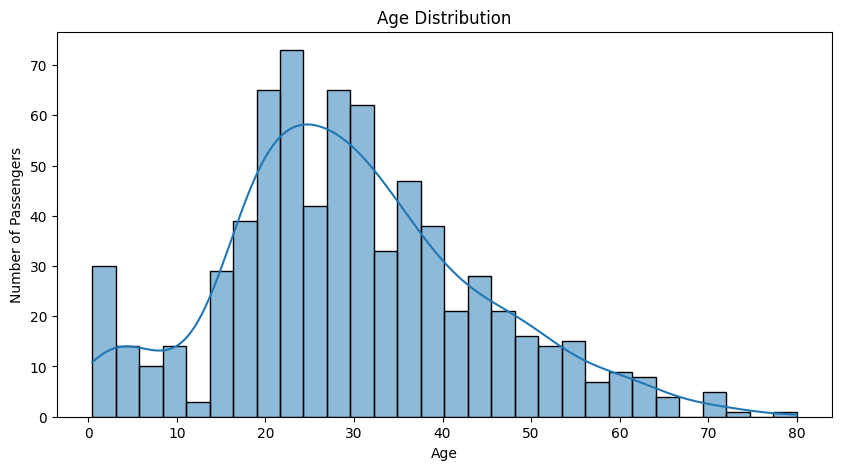

In [ ]:
# =========================================
# 8. Age Analysis
# =========================================

# Check missing values in Age column
train_df["Age"].isnull().sum()

# Visualize age distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    train_df["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

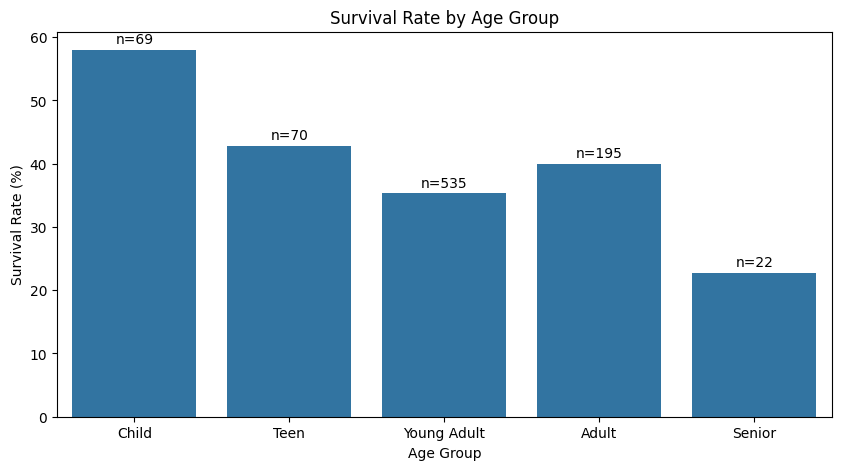

In [ ]:
# =========================================
# 8. Age Analysis
# =========================================
# Create a temporary age column for analysis
train_df["AgeFilled"] = train_df["Age"].fillna(
    train_df["Age"].median()
)
# Group passengers into age categories
train_df["AgeGroup"] = pd.cut(
    train_df["AgeFilled"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[
        "Child",
        "Teen",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)
# Calculate survival rate by age group
age_stats = (
    train_df.groupby("AgeGroup")
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "count")
    )
    .reset_index()
)

age_stats["SurvivalRate"] *= 100

age_stats

# Visualize survival rate by age group
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=age_stats,
    x="AgeGroup",
    y="SurvivalRate"
)

# Add sample size annotations
for i, row in age_stats.iterrows():
    ax.text(
        i,
        row["SurvivalRate"] + 1,
        f'n={row["Count"]}',
        ha='center'
    )

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")

plt.show()

### Key Findings

- Children and teenagers showed higher survival rates than adults and seniors.
- Senior passengers had the lowest survival rates among age groups.
- Most passengers were young adults or adults.
- Age appears to be an important factor associated with survival.

## Fare Analysis

In this section, we analyze ticket fare and its relationship with survival.

Ticket fare may reflect passenger wealth and is often associated with passenger class. We investigate whether passengers who paid higher fares had higher survival rates.

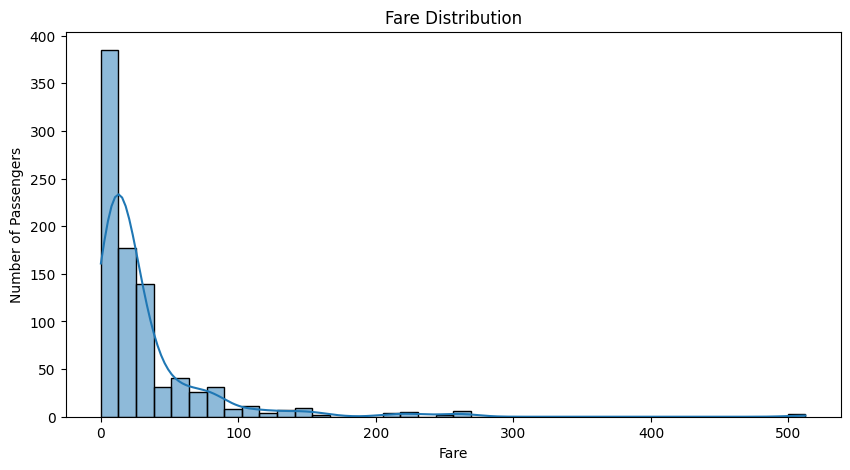

In [ ]:
# =========================================
# 9. Fare Analysis
# =========================================
# Display summary statistics for ticket fare
train_df["Fare"].describe()
# Visualize fare distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    train_df["Fare"],
    bins=40,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
# =========================================
# 9. Fare Analysis
# =========================================
# Divide passengers into fare groups
train_df["FareGroup"] = pd.qcut(
    train_df["Fare"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)
# Calculate survival rate by fare group
fare_stats = (
    train_df.groupby("FareGroup")
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "count")
    )
    .reset_index()
)

fare_stats["SurvivalRate"] *= 100

fare_stats

,FareGroup,SurvivalRate,Count
0,Low,19.730942,223
1,Medium,30.357143,224
2,High,45.495495,222
3,Very High,58.108108,222


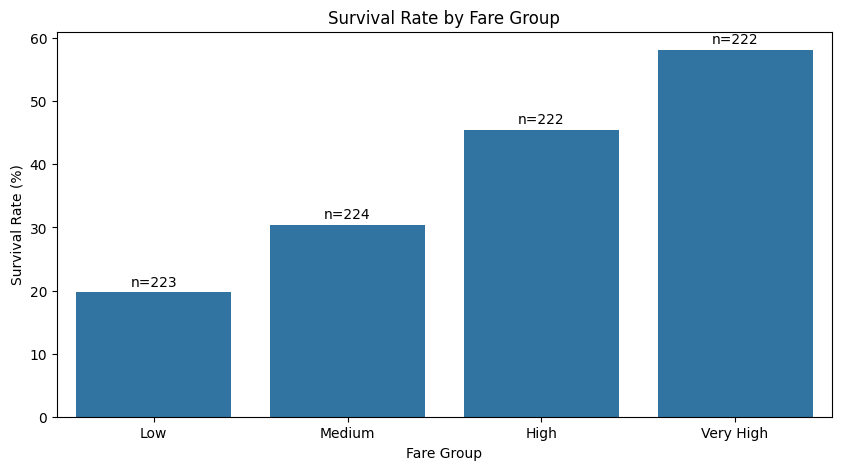

In [ ]:
# =========================================
# 9. Fare Analysis
# =========================================
# Visualize survival rate by fare group
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=fare_stats,
    x="FareGroup",
    y="SurvivalRate"
)

# Add sample size annotations
for i, row in fare_stats.iterrows():
    ax.text(
        i,
        row["SurvivalRate"] + 1,
        f'n={row["Count"]}',
        ha='center'
    )

plt.title("Survival Rate by Fare Group")
plt.xlabel("Fare Group")
plt.ylabel("Survival Rate (%)")

plt.show()

### Key Findings

- Higher ticket fares were associated with higher survival rates.
- Passengers paying the highest fares showed the greatest probability of survival.
- Fare distribution was highly right-skewed, with a small number of very expensive tickets.
- Ticket fare may be related to passenger class and socioeconomic status.

# EDA Summary

The exploratory analysis identified several factors associated with passenger survival:

1. Gender was the strongest predictor of survival.
2. First-class passengers survived more frequently than third-class passengers.
3. Children had higher survival rates than adults and seniors.
4. Small-to-medium family sizes were associated with better survival outcomes.
5. Higher ticket fares were linked to increased survival rates.

These findings will guide the feature selection and preprocessing steps in the machine learning phase of the project.